In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, f1_score


In [ ]:
df = pd.read_csv('/content/googleplaystore_procesados.csv')

#Limpieza de datos

In [ ]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df = df.drop_duplicates()

In [ ]:
df = df.drop(columns=[
    'App', 'Genres', 'Last Updated',
    'Current Ver', 'Android Ver'
])

In [ ]:
def convertir_size(x):
    if isinstance(x, str):
        if 'M' in x:
            return float(x.replace('M',''))
        elif 'k' in x:
            return float(x.replace('k','')) / 1000
    return np.nan

df['Size'] = df['Size'].apply(convertir_size)
df['Size'] = df['Size'].fillna(df['Size'].median())

In [ ]:
le = LabelEncoder()
df['Category'] = le.fit_transform(df['Category'])

In [ ]:
le = LabelEncoder()
df['Sentiment'] = le.fit_transform(df['Sentiment'])

In [ ]:
df['Installs'] = np.log1p(df['Installs'])
df['Reviews'] = np.log1p(df['Reviews'])

In [ ]:
df

,Category,Rating,Reviews,Size,Installs,Price,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Sentiment_Encoded,Type_Free,Type_Paid,Content_Adults only 18+,Content_Everyone,Content_Everyone 10+,Content_Mature 17+,Content_Teen,Estimated_Revenue
0,0,3.9,6.875232,14.0,13.122365,0.0,0,-0.250000,1.000000,1,True,False,False,True,False,False,False,0.0
1,0,3.9,6.875232,14.0,13.122365,0.0,0,-0.725000,0.833333,1,True,False,False,True,False,False,False,0.0
2,0,3.9,6.875232,14.0,13.122365,0.0,1,0.000000,0.000000,2,True,False,False,True,False,False,False,0.0
3,0,3.9,6.875232,14.0,13.122365,0.0,3,0.157320,0.494162,0,True,False,False,True,False,False,False,0.0
4,0,3.9,6.875232,14.0,13.122365,0.0,2,0.500000,0.600000,3,True,False,False,True,False,False,False,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41656,6,4.4,10.518187,4.0,13.815512,0.0,1,0.000000,0.000000,2,True,False,False,True,False,False,False,0.0
41657,6,4.4,10.518187,4.0,13.815512,0.0,2,0.493750,0.700000,3,True,False,False,True,False,False,False,0.0
41658,6,4.4,10.518187,4.0,13.815512,0.0,2,0.535119,0.714286,3,True,False,False,True,False,False,False,0.0
41659,6,4.4,10.518187,4.0,13.815512,0.0,2,0.225000,0.426786,3,True,False,False,True,False,False,False,0.0


In [ ]:
X = df.drop(columns=['Installs'])
y = df['Installs']

In [ ]:
np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=7)

#Entrenamiento Modelo Regresión Logistica

In [ ]:
#Entrenar modelo

clf = LinearRegression()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [ ]:
# Evaluar

print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 0.7416036604109044
MAE: 0.661619404096446
R2: 0.8762039247335213


##Entrenamiento Modelo RandomForestRegression

In [ ]:

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R2 Random Forest:", r2_score(y_test, y_pred_rf))

R2 Random Forest: 0.9983437479854749


##Comparación entre modelos

Random Forest posee un R2 mas alto, por lo tanto es un modelo Supervisado mas indicado para la base de datos en comparacion al modelo de regresión lineal

##Entrenamiento Modelo K-Means

In [ ]:
features = ['Reviews', 'Installs', 'Size', 'Price']
X = df[features]

Redefinimos X para K-Means

###Seleccion de K correcto

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

best_k = 2
best_score = -1

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    print(f"K={k}, score={score}")

    if score > best_score:
        best_score = score
        best_k = k

print("Mejor K:", best_k)

K=2, score=0.4083566865941731
K=3, score=0.3940515157199243
K=4, score=0.39358713143693735
K=5, score=0.37248024065248864
K=6, score=0.39631054421687567
K=7, score=0.39984406710533005
K=8, score=0.40236276389243036
K=9, score=0.36391893701509204
Mejor K: 2


###K-Means

In [ ]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
model=KMeans(n_clusters=best_k, random_state=42)
model.fit(X_scaled)
label=model.predict(X_scaled)
print(label)

[1 1 1 ... 1 1 1]


<Axes: xlabel='Reviews', ylabel='Installs'>

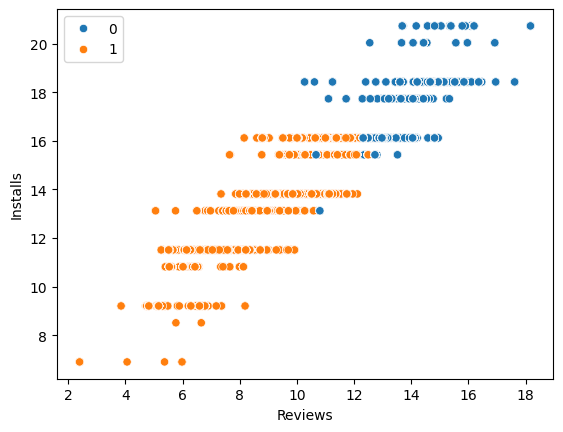

In [ ]:
sns.scatterplot(x=df['Reviews'], y=df['Installs'], hue=label)

In [ ]:
kmeans = KMeans(n_clusters=best_k, random_state=42)
labels = kmeans.fit_predict(X_scaled)
score = silhouette_score(X_scaled,labels)
print("Silhouette score: ", score)

Silhouette score:  0.4083566865941731


##Optimizacion de Hiperparametros para RandomForest

In [ ]:
X = df.drop(columns=['Installs'])
y = df['Installs']

param_grid = {'n_estimators':[50,100, 200], 'max_depth': [2,4,6]} #Posibles variables para numero de estimadores y profundidad

clf = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)

clf.fit(X,y)

GridSearchCV(cv=3, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [2, 4, 6],
                         'n_estimators': [50, 100, 200]})

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

print("Mejores Parametros: ", clf.best_params_)

R2: 0.9247349172740483
MSE: 0.45087746708081056
MAE: 0.43422699881269883
Mejores Parametros:  {'max_depth': 6, 'n_estimators': 200}


In [ ]:
# Convertir cv_results_ a un DataFrame
resultados_df = pd.DataFrame(clf.cv_results_)

# Seleccionar solo las columnas más relevantes para ver el accuracy y los parámetros
columnas_relevantes = ['param_max_depth', 'param_n_estimators', 'mean_test_score', 'std_test_score', 'rank_test_score']
tabla_resumen = resultados_df[columnas_relevantes].sort_values(by='rank_test_score')

print("\nResumen completo del GridSearch:")
print(tabla_resumen)


Resumen completo del GridSearch:
   param_max_depth  param_n_estimators  mean_test_score  std_test_score  \
8                6                 200         0.833774        0.048939   
7                6                 100         0.832768        0.050480   
6                6                  50         0.832262        0.051273   
3                4                  50         0.824970        0.027176   
5                4                 200         0.824495        0.027800   
4                4                 100         0.823916        0.028124   
1                2                 100         0.738511        0.045230   
2                2                 200         0.738370        0.045370   
0                2                  50         0.738161        0.045564   

   rank_test_score  
8                1  
7                2  
6                3  
3                4  
5                5  
4                6  
1                7  
2                8  
0                9  


In [ ]:
best_model = clf.best_estimator_

y_pred = best_model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))

R2: 0.9247349172740483
